### Imports & Configuration

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cuda"
# os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import numpy as np

import jax
import jax.numpy as jnp
print(jax.devices())
print(jax.default_backend())

import joblib

import tensorflow.keras as K

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

[CudaDevice(id=0)]
gpu


In [2]:
params = {
               "k1" : 0.1,   # min: 0.001 || max: 0.6
               "k2" : 0.1,   # min: 0.001 || max: 0.6
              "x12" : 0.2,   # min: -1    || max: 1
              "Om0" : 0.3,   # min: 0.1   || max: 0.4
         "log10fR0" : -5.7,  # max: -7    || max: -4
            "z_max" : 1.7,   #            || max: 1
            "invH0" : 2997.92458,
       "batch_size" : 64,
           "etaini" : -4,
          "N_steps" : 4,
    "path_datasets" : "./src/datasets/",
       "path_model" : "./src/model/"
}

In [3]:
_RC = {
    # Tipografía
    "font.family":          "serif",
    "mathtext.fontset":     "cm",
    # Tamaños base
    "axes.titlesize":       13,
    "axes.labelsize":       12,
    "xtick.labelsize":      10,
    "ytick.labelsize":      10,
    "legend.fontsize":      9.5,
    # Leyenda
    "legend.framealpha":    0.90,
    "legend.edgecolor":     "0.75",
    "legend.handlelength":  2.0,
    # Cuadrícula
    "axes.grid":            True,
    "grid.linestyle":       ":",
    "grid.linewidth":       0.5,
    "grid.alpha":           0.50,
    # Bordes
    "axes.spines.top":      False,
    "axes.spines.right":    False,
    # Layout y guardado
    "figure.constrained_layout.use": True,
    "savefig.dpi":          600,
    "savefig.bbox":         "tight",
}

_C_TRUE = "#1B4F9B"   # azul profundo   → valores numéricos
_C_PRED = "#C0392B"   # rojo oscuro     → predicción emulador
_C_FILL = "#EAB7B2"   # rojo suave      → banda de diferencia
_C_F2   = "#1B4F9B"   # azul            → F₂
_C_G2   = "#D35400"   # naranja oscuro  → G₂
_C_HIST = "#2980B9"   # azul claro      → barras histograma
_C_P99  = "#C0392B"   # rojo            → línea de percentil 99

_NAMES  = [r"\mathcal{A}", r"\mathcal{A}^{\prime}", r"\mathcal{B}", r"\mathcal{B}^{\prime}"]
_DELTA_NAMES = [r"$\Delta\mathcal{A}\;[\%]$", r"$\Delta\mathcal{A}^{\prime}\;[\%]$",
                r"$\Delta\mathcal{B}\;[\%]$", r"$\Delta\mathcal{B}^{\prime}\;[\%]$"]

In [4]:
def importModel():
    path_model = params["path_model"]

    global scaler_i
    global scaler_o
    scaler_i = joblib.load(path_model + "scaler_i.pkl")
    scaler_o = joblib.load(path_model + "scaler_o.pkl")
    
    model = K.models.load_model(path_model + "model.keras")
    
    return model

In [5]:
def loadData():
    path_datasets = params["path_datasets"]
    
    test = np.loadtxt(path_datasets + "test.txt", skiprows=1)
    # test[:,5] = 10**test[:,5]
        
    print("Samples size:")
    print(f"Test: {len(test)}.\n")

    return test

### Relative error

In [6]:
def scaleData(data_set):
    """
    Divide los 6 imputs y 4 outputs ded cada data set.

    Se crea 2 SS y 2 scalers para input y output. Los scalers solo se crean con train
    para impedir que el modelo sepa de antemano información de validation o test.
    """
    i_set, o_set = data_set[:,:6], data_set[:,6:]    # (z, k1, k2, x12, om, logf), (A, Ap, B, Bp)
        
    return [scaler_i.transform(i_set), scaler_o.transform(o_set)]

In [7]:
def _unScaleData(data):
    """
    Aplica el escalamiento inverso para obtener los valores en los rangos originales.bien. 
    """
    return scaler_o.inverse_transform(data)

In [8]:
def _makePrediction(x_data):
    batch_size = params["batch_size"]

    prediction = model.predict(
        x_data,
        batch_size=batch_size,
        verbose=0,
    )

    return prediction

In [9]:
def _calcPercentil(error):
    r_names = ["A", "Ap", "B", "Bp"]
    rows = len(r_names)

    print(f"Percentil 99 for unscaled data in relative percentual error")
    print(20 * "=")
    for r in range(rows):
        perc = np.percentile(np.abs(error.T[r]), 99)
        print(f"{r_names[r]:>4}: {perc:.6f}%")
    print(20 * "=")

In [33]:
def _plotComparation(scaled_x, unscaled_y, unscaled_y_predic):
    # ── Desescalar y seleccionar bloque z ─────────────────────────────────
    N_group    = 64
    unscaled_x = scaler_i.inverse_transform(scaled_x)
    idx        = np.argsort(unscaled_x[:N_group, 0])
    z_arr      = unscaled_x[:N_group][idx, 0]
    y_true     = unscaled_y[:N_group][idx]
    y_pred     = unscaled_y_predic[:N_group][idx]
    k1_v, k2_v, x12_v, Om0_v, lfR0_v = unscaled_x[0, 1:]

    # ── Construir figura ──────────────────────────────────────────────────
    _rc_local = {**_RC, "figure.constrained_layout.use": False}
    with plt.rc_context(_rc_local):

        fig = plt.figure(figsize=(11, 10))

        # Grilla exterior 2×2 (cada celda = 1 panel compuesto)
        outer = GridSpec(
            2, 2, figure=fig,
            hspace=0.15, wspace=0.30,
            top=0.93, bottom=0.07, left=0.09, right=0.97,
        )

        axes_m, axes_r = [], []
        for i in range(2):
            for j in range(2):
                # Sub-grilla interior: panel principal (alto 3) + residual (alto 1)
                inner = GridSpecFromSubplotSpec(
                    2, 1,
                    subplot_spec=outer[i, j],
                    height_ratios=[3, 1],
                    hspace=0.06,
                )
                ax_m = fig.add_subplot(inner[0])
                ax_r = fig.add_subplot(inner[1], sharex=ax_m)
                axes_m.append(ax_m)
                axes_r.append(ax_r)
                plt.setp(ax_m.get_xticklabels(), visible=False)  # ocultar x en main

        fig.suptitle(
            r"Comparación entre resultados numéricos vs emulados",
            fontsize=14, fontweight="bold",
        )

        # ── Cuadro de parámetros en panel A' (k=1) ───────────────────────
        param_text = "\n".join([
            "Configuración de modo",
            rf"$k_1 = {k1_v:.4f}\ h\,\mathrm{{Mpc}}^{{-1}}$",
            rf"$k_2 = {k2_v:.4f}\ h\,\mathrm{{Mpc}}^{{-1}}$",
            rf"$x_{{12}} = \hat{{k}}_1\cdot\hat{{k}}_2 = {x12_v:.4f}$",
            "",
            "Parámetros cosmológicos",
            rf"$\Omega_m = {Om0_v:.4f}$",
            rf"$\log_{{10}}(fR_0) = {lfR0_v:.4f}$",
        ])
        axes_m[1].text(
            0.97, 0.04,
            param_text,
            transform=axes_m[1].transAxes,
            ha="right", va="bottom",
            fontsize=8.2,
            linespacing=1.6,
            bbox=dict(
                boxstyle="round,pad=0.55",
                facecolor="#FEFCE8",    # crema suave
                alpha=0.93,
                edgecolor="0.55",
                linewidth=0.9,
            ),
        )

        # ── Paneles ───────────────────────────────────────────────────────
        for k, (ax_m, ax_r) in enumerate(zip(axes_m, axes_r)):
            truth   = y_true[:, k]
            pred    = y_pred[:, k]
            rel_pct = (pred / truth - 1.0) * 100.0   # Δy [%]

            # — Panel principal —
            ax_m.plot(z_arr, truth, color=_C_TRUE, lw=1.8,
                      label="Numérico", zorder=3)
            ax_m.plot(z_arr, pred,   color=_C_PRED, lw=1.4, ls="--",
                      label="Emulador", zorder=3)
            ax_m.fill_between(z_arr, truth, pred,
                              color=_C_FILL, alpha=0.30, zorder=2)
            ax_m.set_ylabel(rf"${_NAMES[k]}$", fontsize=12)
            # ax_m.set_title(_NAMES[k], fontsize=13, pad=5)
            if k == 0:
                ax_m.legend(loc="lower right", fontsize=9)

            # — Panel residual —
            ax_r.plot(z_arr, rel_pct, color="0.20", lw=1.2, zorder=3)
            ax_r.axhline(0.0, color="0.50", lw=0.7, ls=":", zorder=2)
            ax_r.fill_between(
                z_arr, rel_pct, 0.0,
                where=(rel_pct >= 0), color=_C_TRUE, alpha=0.15, zorder=1,
            )
            ax_r.fill_between(
                z_arr, rel_pct, 0.0,
                where=(rel_pct < 0),  color=_C_PRED, alpha=0.15, zorder=1,
            )

            amax = max(np.abs(rel_pct).max() * 1.35, 0.02)
            ax_r.set_ylim(-amax, amax)
            ax_r.set_ylabel(rf"{_DELTA_NAMES[k]}", fontsize=9, labelpad=2)
            ax_r.yaxis.set_major_locator(
                mticker.MaxNLocator(nbins=3, symmetric=True)
            )
            ax_r.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
            ax_r.tick_params(axis="both", labelsize=8)

        # Etiqueta x sólo en paneles residuales inferiores (k=2,3)
        for ax_r in axes_r[2:]:
            ax_r.set_xlabel(r"Redshift $z$", fontsize=11)

        plt.savefig("comparation.pdf")
        plt.show()

In [11]:
def relError(scaled_data):
    scaled_x, scaled_y = scaled_data[0], scaled_data[1]
    scaled_y_predic    = _makePrediction(scaled_x)

    unscaled_y         = _unScaleData(scaled_y)
    unscaled_y_predic  = _unScaleData(scaled_y_predic)
        
    #unscaled_abs_error = (unscaled_y - unscaled_y_predic) * 100
    unscaled_rel_error = (1 - unscaled_y_predic / unscaled_y) * 100

    _calcPercentil(unscaled_rel_error)

    _plotComparation(scaled_x, unscaled_y, unscaled_y_predic)
    return unscaled_rel_error

In [12]:
def plotRelError(rel_error):
    with plt.rc_context(_RC):
        fig, axes = plt.subplots(2, 2, figsize=(11, 8))
        fig.suptitle(
            "Error relativo porcentual del emulador",
            fontsize=14, fontweight="bold",
        )

        for c in range(2):
            for r in range(2):
                k   = r * 2 + c
                ax  = axes[r, c]
                err = rel_error.T[k]

                # ── Percentil 99 adaptativo ──────────────────────────────
                p99 = float(np.percentile(np.abs(err), 99))
                rng = (-p99 * 1.08, p99 * 1.08)

                n, bins, _ = ax.hist(
                    err, bins=60, range=rng,
                    log=True, orientation="horizontal",
                    color=_C_HIST, alpha=0.75,
                    edgecolor="white", linewidth=0.2,
                )

                # ── Línea de percentil 99 ────────────────────────────────
                ax.axhline(+p99, color=_C_P99, lw=1.6, ls="--", zorder=5,
                           label=rf"$p_{{99}} = {p99:.2f}\%$")
                ax.axhline(-p99, color=_C_P99, lw=1.6, ls="--", zorder=5)
                ax.axhline(0.0,  color="0.40", lw=0.8, ls=":",  zorder=4)

                # Zona sombreada fuera del percentil 99
                ax.axhspan(+p99,  rng[1], color=_C_P99, alpha=0.07, zorder=1)
                ax.axhspan(rng[0], -p99,  color=_C_P99, alpha=0.07, zorder=1)

                ax.set_ylabel(
                    rf"$\Delta\,{_NAMES[k]}\;[\%]$", fontsize=12, labelpad=3
                )
                ax.set_xlabel("Frecuencia", fontsize=11)
                # ax.set_title(
                #     rf"Error relativo de {_NAMES[k]}", fontsize=12
                # )
                ax.set_ylim(rng)
                ax.legend(fontsize=9, loc="lower right",
                          handlelength=1.2, framealpha=0.85)

        plt.savefig("error.pdf")
        plt.show()

### Kernels

In [13]:
def Omega_m(eta):
    return 1.0 / (1.0 + (1.0 - Om0) / Om0 * jnp.exp(3.0 * eta))

In [14]:
def H_func(eta):
    return jnp.sqrt(Om0 * jnp.exp(-3.0 * eta) + (1.0 - Om0))

In [15]:
def f1(eta):
    return 2.0 - 1.5 * Omega_m(eta)

In [16]:
def f2(eta):
    return 1.5 * Omega_m(eta)

In [17]:
def rhs_f0(eta, f0):
    return f2(eta) - f0**2 - f1(eta) * f0

In [18]:
@jax.jit
def compute_f0(eta_ev):
    etaini  = params["etaini"]
    N_steps = params["N_steps"]

    eta_array = jnp.linspace(etaini, eta_ev, N_steps)
    dt = eta_array[1] - eta_array[0]

    def step_fn(f0, eta):
        k1 = rhs_f0(eta,            f0)
        k2 = rhs_f0(eta + 0.5 * dt, f0 + 0.5 * dt * k1)
        k3 = rhs_f0(eta + 0.5 * dt, f0 + 0.5 * dt * k2)
        k4 = rhs_f0(eta + dt,       f0 + dt * k3)
        return f0 + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4), None

    f0_final, _ = jax.lax.scan(step_fn, 1.0, eta_array[:-1])
    return f0_final

In [19]:
def calKernels(z_arr, AB_functions):
    A, Ap, B, Bp = AB_functions.T
    eta   = -np.log(1 + z_arr)
    Om0   = params["Om0"]
    invH0 = params["invH0"]

    k12  = k1 * k2
    dotk = k1 * k2 * x12
    f12  = f1(eta) + f2(eta)
    H_eta = invH0 * H_func(eta)

    f0 = jax.vmap(lambda e: compute_f0(e))(jnp.array(eta))

    F2 = (
        0.5
        + (3.0 / 14.0) * A
        + (0.5 - (3.0 / 14.0) * B) * dotk**2 / k12**2
        + dotk / (2 * k12) * (k1 / k2 + k2 / k1)
    )

    G2 = (
        (3.0 * A * f12 + 3.0 * Ap / H_eta) / (14.0 * f0)
        + (f12 / (2 * f0) - (3 * B * f12 + 3 * Bp / H_eta) / (14.0 * f0))
          * dotk**2 / k12**2
        + dotk / (2 * k12) * (
              (f2(eta) * k2) / (f0 * k1)
            + (f1(eta) * k1) / (f0 * k2)
          )
    )

    return F2, G2

In [20]:
def emulate(z_arr, args):
    z_len = len(z_arr)
    N_args = len(args)
    
    args = np.tile(args, z_len).reshape(z_len, N_args)
    x_data = np.hstack([z_arr.reshape(z_len, 1), args])
    
    scaled_x_data = scaler_i.transform(x_data)
    scaled_y_predic = _makePrediction(scaled_x_data)
    unscaled_y_predic = scaler_o.inverse_transform(scaled_y_predic)

    return unscaled_y_predic

In [35]:
def plotKernels(z_arr, F2, G2, F2_gr=None, G2_gr=None):
    data = [(F2, _C_F2, r"$F_2(z)$"), (G2, _C_G2, r"$G_2(z)$")]
    refs = [F2_gr, G2_gr]

    with plt.rc_context(_RC):
        fig, axes = plt.subplots(1, 2, figsize=(11, 3))
        fig.suptitle(
            r"Kernels $F_2(z)$ y $G_2(z)$ emulados",
            fontsize=13, fontweight="bold",
        )

        _gr_labels = [r"$F_2^{\rm GR}(z)$", r"$G_2^{\rm GR}(z)$"]
        for i, (ax, (vals, color, label), ref) in enumerate(zip(axes, data, refs)):
            # ── Curva principal ──────────────────────────────────────────
            ax.plot(z_arr, vals, color=color, lw=2.0,
                    label=label, zorder=3)

            # ── Referencia GR (si se proporcionó) ───────────────────────
            if ref is not None:
                ax.plot(z_arr, ref, color="0.50", lw=1.2, ls="--",
                        label=_gr_labels[i], zorder=2)
                # Banda de desviación respecto a GR
                ax.fill_between(z_arr, vals, ref,
                                color=color, alpha=0.12, zorder=1,
                                label=r"$\Delta$ (mod. grav.)")

            # ── Línea punteada en z=0 ────────────────────────────────────
            ax.axhline(vals[0], color=color, lw=0.8, ls=":",
                       alpha=0.55, zorder=2)
            ax.text(
                0.03, 0.97,
                rf"$z=0$: {vals[0]:.4f}",
                transform=ax.transAxes, ha="left", va="top",
                fontsize=8.5, color=color,
                bbox=dict(boxstyle="round,pad=0.25",
                          facecolor="white", alpha=0.75, edgecolor="none"),
            )

            ax.set_xlabel(r"Redshift $z$", fontsize=12)
            ax.set_ylabel(label, fontsize=12)
            # ax.set_title(label, fontsize=13)
            ax.legend(fontsize=9.5, loc="upper right")

        plt.savefig("kernels.pdf")
        plt.show()

### Main

Samples size:
Test: 1048576.

Percentil 99 for unscaled data in relative percentual error
   A: 0.029098%
  Ap: 33.209702%
   B: 0.013814%
  Bp: 29.818796%


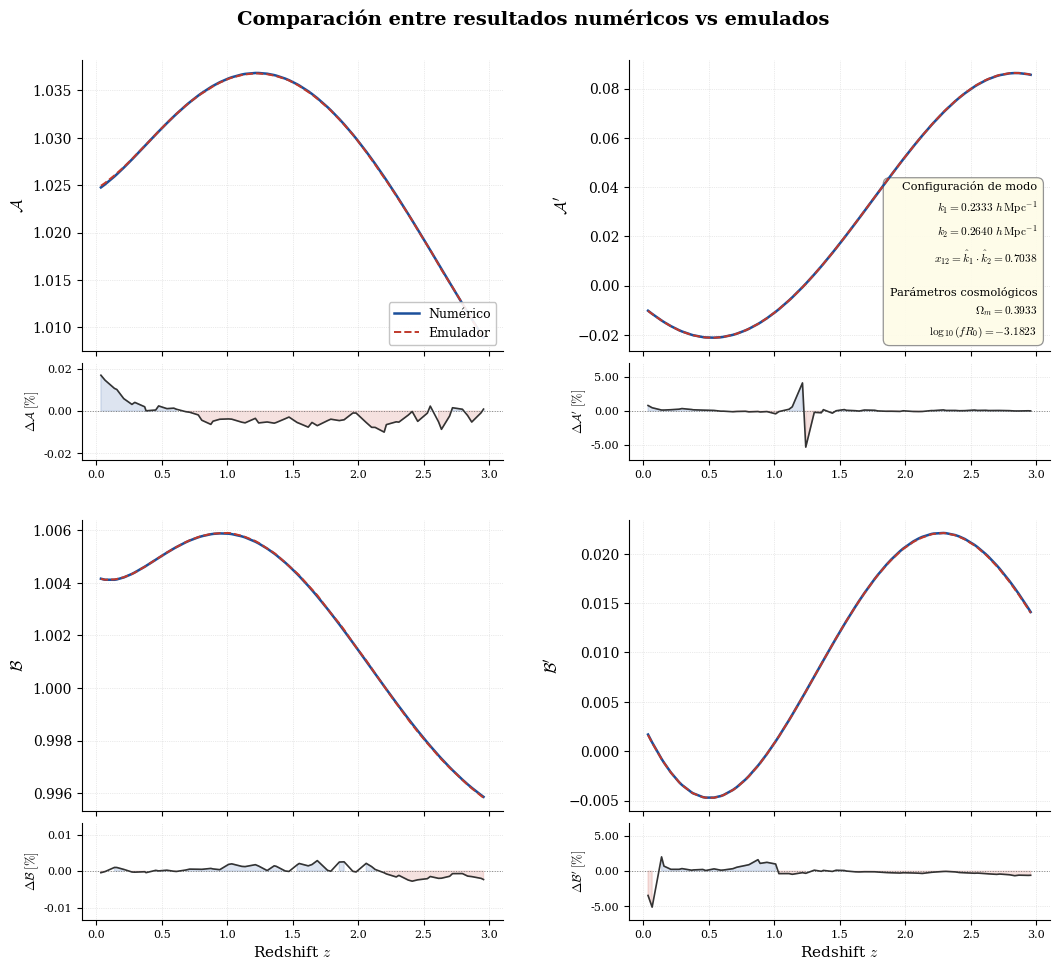

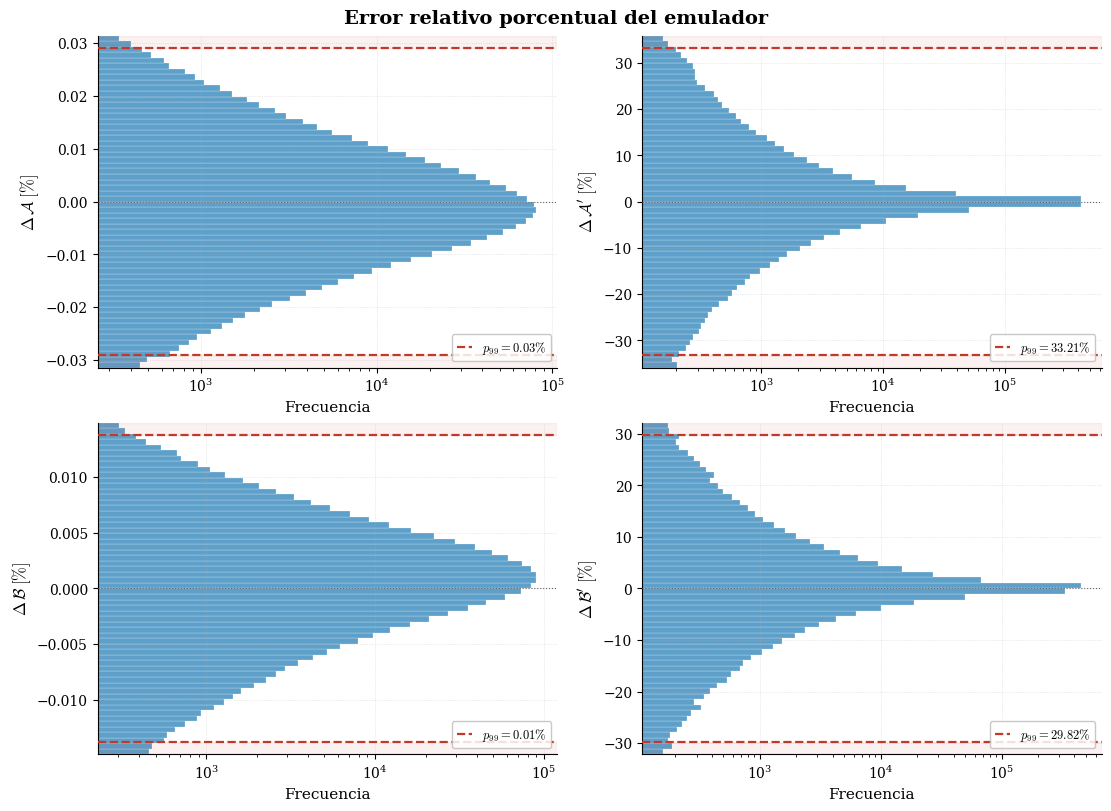

CPU times: user 28.6 s, sys: 2.7 s, total: 31.3 s
Wall time: 25.8 s


In [34]:
%%time
model = importModel()
test  = loadData()

scaled_test = scaleData(test)
test_error = relError(scaled_test)

plotRelError(test_error)

In [23]:
%%time
k1       = params["k1"]
k2       = params["k2"]
x12      = params["x12"]
Om0      = params["Om0"]
fR0      = 10**params["log10fR0"]
z_max    = params["z_max"]

z_arr = np.linspace(0, z_max, 100)
args = np.array([k1, k2, x12, Om0, fR0])

AB_functions = emulate(z_arr, args)

F2, G2 = calKernels(z_arr, AB_functions)

CPU times: user 8.35 s, sys: 682 ms, total: 9.03 s
Wall time: 4.76 s


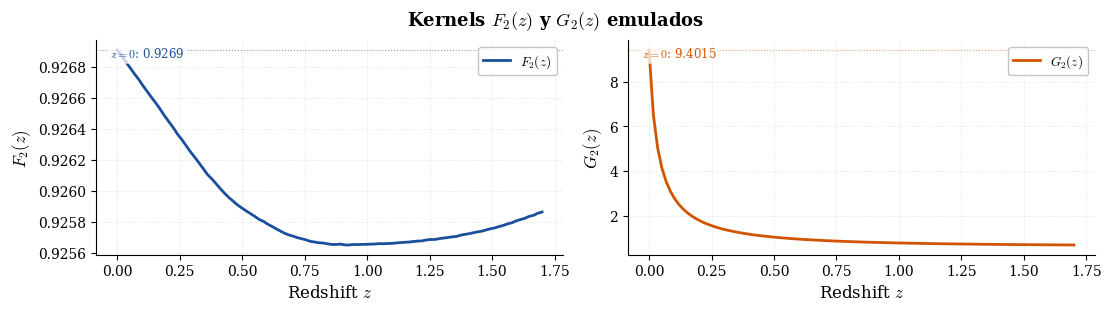

In [36]:
plotKernels(z_arr, F2, G2)